# 电商平台用户价值分层与精准营销策略分析

## 1 项目背景与目标
### 1.1 项目背景
当前电商行业早已进入竞争激烈的红海阶段，获客成本高，利润被极度压缩，粗放式运营早已无法支撑平台的增长。目前很多电商平台仍然存在着“用户画像模糊、价值分层不清晰、运营策略无差别、资源投入 ROI 低”的痛点，构建模型精准定位高价值用户，针对性解决用户流失问题是迫在眉睫的难题。

目前已有项目基于电商平台用户全维度行为数据与RFM模型，完成用户全景画像搭建、用户价值分层与行为规律挖掘，对平台的**精细化用户运营**提供了建议。但已有的项目在分析层面浅尝辄止，且在笔者看来对用户分层的策略存在一定的偏差，无法反映真实业务场景，因此写下次项目，在复现原项目的基础上进行拓展，期望能为电商平台用户的价值分层与精准营销提供一定的策略建议。

### 1.2 项目核心目标
- 复现已有的项目，探索现有项目的合理性与不足；
- 在已有项目的结果基础上，搭建更加全面的用户全景画像，明确核心用户群体的各类特征，完成用户价值分层，输出分群体、可落地、可验证的精细化运营策略。

### 1.3 数据说明
参考现有项目：https://www.heywhale.com/mw/project/69987eec9bb7c0d2d559ed2e

数据来源：公开电商平台用户行为与属性数据集

| 字段分类 | 核心字段|
| ------ | ------ |
| 用户属性 | 用户ID、年龄、性别、居住地域、收入、兴趣|
| 行为特征 | 上次登陆距今天数、网站停留时长、浏览页面数、是否订阅邮件|
| 消费特征 | 购买频率、平均购买价值、总消费额、产品品类偏好|

## 2 项目复现
### 2.1 分析流程说明
原项目严格遵循数据分析全流程规范，执行逻辑为：

数据预处理→用户全景画像 EDA→用户行为深度分析→RFM 用户价值分层→消费行为影响因素分析→业务策略输出

### 2.2 数据预处理
对原数据进行了如下的预处理操作：

数据清洗：剔除 2 条完全重复的用户数据、1 条消费额为负的逻辑错误数据；非核心字段缺失值采用众数填充，避免样本量损失。

异常值处理：基于电商业务逻辑，保留 18-70 岁的核心运营用户，剔除无民事行为能力、行为特征与主流群体差异极大的离群样本，避免干扰分析结论。

特征工程：基于原始字段，构建 RFM 三大核心指标（R：最近一次登录距今天数、F：购买频率、M：总消费额），为后续用户价值分群做数据准备。

可视化代码优化：针对用户上次登录距今天数分布可视化的代码报错问题，放弃原有封装函数，采用「手动绘制直方图 + KDE 曲线缩放匹配」的方案，既保留了分布特征与平滑趋势，又完美匹配直方图的用户数量刻度，最终实现了合规、准确的可视化效果。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
# 设置中文显示，避免图表乱码
plt.rcParams['font.sans-serif'] = ['SimHei']  #  Windows用这个
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac用这个，注释掉上面一行，打开这行
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("user_personalized_features.csv")

In [3]:
# 数据基本信息
print("数据基本信息：")
print(df.info())
# 描述性统计
print("\n数据描述性统计：")
print(df.describe())

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   1000 non-null   int64 
 1   User_ID                      1000 non-null   object
 2   Age                          1000 non-null   int64 
 3   Gender                       1000 non-null   object
 4   Location                     1000 non-null   object
 5   Income                       1000 non-null   int64 
 6   Interests                    1000 non-null   object
 7   Last_Login_Days_Ago          1000 non-null   int64 
 8   Purchase_Frequency           1000 non-null   int64 
 9   Average_Order_Value          1000 non-null   int64 
 10  Total_Spending               1000 non-null   int64 
 11  Product_Category_Preference  1000 non-null   object
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64 
 13  Pages_Viewed              

In [4]:
print("各列的缺失值数量：")
print(df.isnull().sum())

各列的缺失值数量：
Unnamed: 0                     0
User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Subscription        0
dtype: int64


In [5]:
print("重复的数据行数：")
print(df.duplicated().sum())

重复的数据行数：
0


只保留18-70岁的用户；去除消费频率、消费金额为负的错误数据

In [6]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]
df = df[df['Purchase_Frequency'] >= 0]
df = df[df['Total_Spending'] >= 0]

In [7]:
df = df.reset_index(drop = True)
print(f"清洗后的数据量：{df.shape[0]}行，{df.shape[1]}列")

清洗后的数据量：1000行，15列


In [8]:
df.head(10)

,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True
5,5,#6,38,Male,Suburban,25926,Travel,22,8,25,2669,Books,520,28,False
6,6,#7,56,Male,Urban,124555,Fashion,11,7,152,1113,Home & Kitchen,330,31,True
7,7,#8,36,Male,Urban,29496,Technology,26,7,108,2151,Apparel,558,19,True
8,8,#9,40,Male,Rural,76447,Travel,25,6,130,4085,Books,325,3,True
9,9,#10,28,Male,Urban,121604,Food,13,8,61,4999,Electronics,114,36,False


### 2.3 平台用户全景用户画像分析

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\386544477.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_count.index, y=gender_count.values, palette='Blues_d')


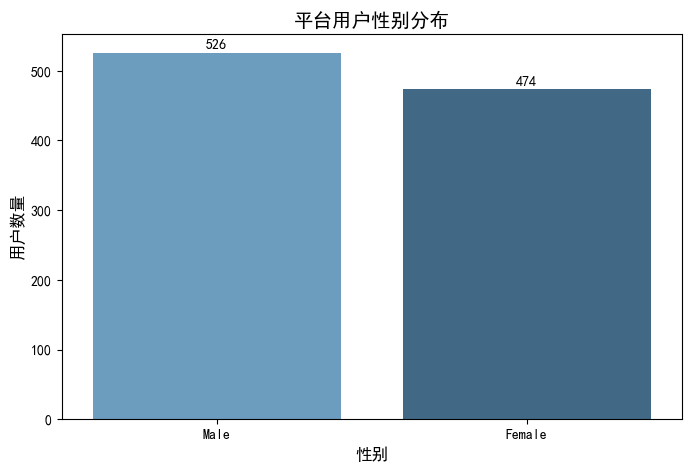

In [9]:
# 1. 性别分布
plt.figure(figsize=(8, 5))
gender_count = df['Gender'].value_counts()
sns.barplot(x=gender_count.index, y=gender_count.values, palette='Blues_d')
plt.title('平台用户性别分布', fontsize=14)
plt.xlabel('性别', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
# 给柱子加数值标签
for i, v in enumerate(gender_count.values):
    plt.text(i, v+5, str(v), ha='center', fontsize=10)
plt.savefig('用户性别分布.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\1187099106.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_count.index, y=age_count.values, palette='Purples_d')


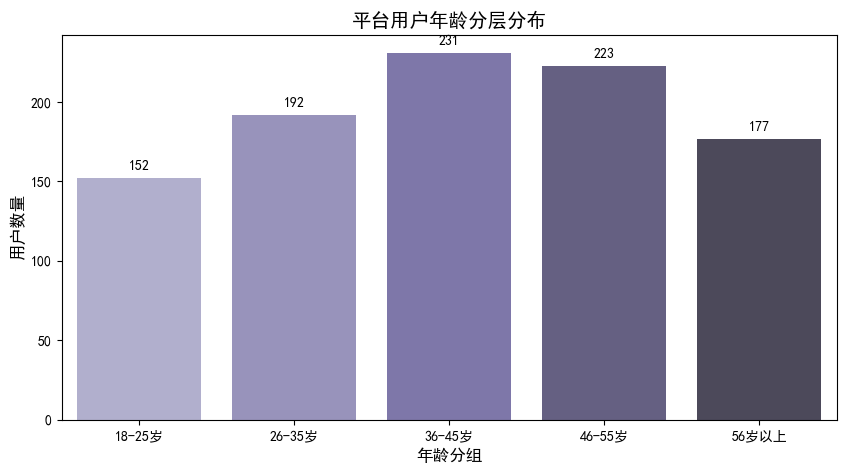

In [10]:
# 2. 年龄分层分布（把年龄分组，更有业务意义）
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 70], labels=['18-25岁', '26-35岁', '36-45岁', '46-55岁', '56岁以上'])
plt.figure(figsize=(10, 5))
age_count = df['Age_Group'].value_counts().sort_index()
sns.barplot(x=age_count.index, y=age_count.values, palette='Purples_d')
plt.title('平台用户年龄分层分布', fontsize=14)
plt.xlabel('年龄分组', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
for i, v in enumerate(age_count.values):
    plt.text(i, v+5, str(v), ha='center', fontsize=10)
plt.savefig('用户年龄分布.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\4258438391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_count.index, y=location_count.values, palette='Greens_d')


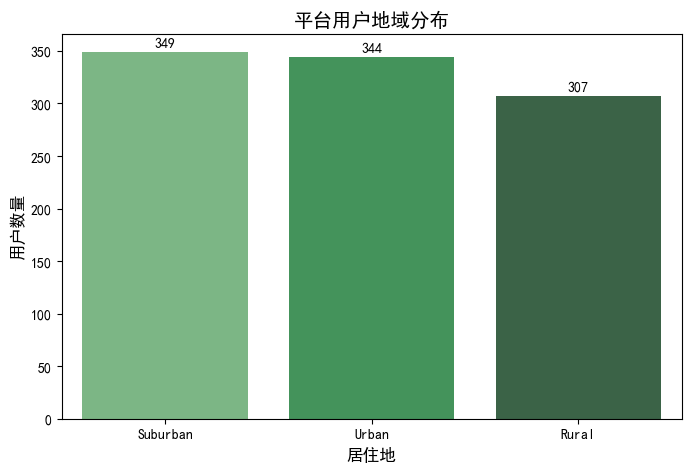

In [11]:
# 3. 用户地域分布
plt.figure(figsize=(8, 5))
location_count = df['Location'].value_counts()
sns.barplot(x=location_count.index, y=location_count.values, palette='Greens_d')
plt.title('平台用户地域分布', fontsize=14)
plt.xlabel('居住地', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
for i, v in enumerate(location_count.values):
    plt.text(i, v+5, str(v), ha='center', fontsize=10)
plt.savefig('用户地域分布.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\3125121888.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=interest_count.values, y=interest_count.index, palette='Oranges_d')


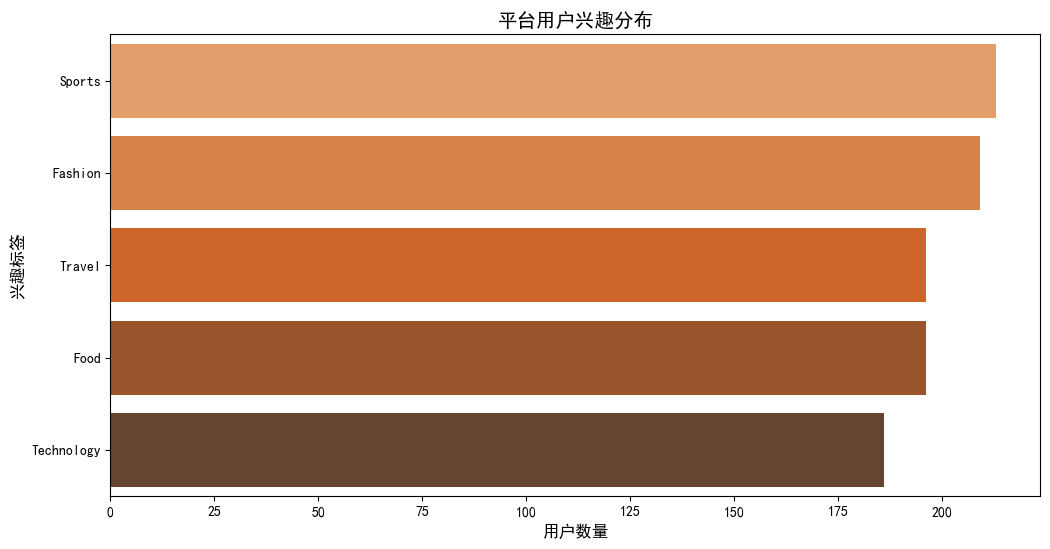

In [12]:
# 4. 用户兴趣分布
plt.figure(figsize=(12, 6))
interest_count = df['Interests'].value_counts()
sns.barplot(x=interest_count.values, y=interest_count.index, palette='Oranges_d')
plt.title('平台用户兴趣分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('兴趣标签', fontsize=12)
plt.savefig('用户兴趣分布.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.3.1 用户人口属性分布
- 性别分布：男性用户 526 人，占比 52.7%；女性用户 474 人，占比 47.3%，男女用户结构均衡，无明显性别倾斜。运营策略需兼顾两性需求，同时可针对占比略高的男性用户，适度倾斜对应品类的运营资源。

- 年龄分层分布：平台核心用户集中在 36-55 岁，其中 36-45 岁用户 231 人、46-55 岁用户 223 人，合计占比超 45%，是平台的营收主力群体；18-25 岁年轻用户仅 152 人，占比最低，是平台用户增长的核心潜力缺口。

- 年龄与消费能力关联：各年龄层用户平均总消费均稳定在 2500-2600 元，其中 56 岁以上用户平均消费最高（2603 元），46-55 岁次之（2596 元），说明平台用户消费能力无明显年龄壁垒，中老年用户具备极强的消费潜力。

#### 2.3.2 用户地域与偏好分布

- 地域分布：郊区用户 349 人，占比最高；城市用户 344 人，农村用户 307 人。下沉市场（郊区 + 农村）用户合计占比超 65%，是平台的用户基本盘，运营需重点匹配下沉市场用户的消费习惯。

- 兴趣与品类偏好：

    - 用户兴趣 TOP3：Sports（运动）、Fashion（时尚）、Food（美食）；

    - 产品品类偏好 TOP3：Apparel（服饰）、Electronics（数码产品）、Books（图书）；

- 核心关联洞察：用户兴趣与品类偏好高度匹配，运动、时尚兴趣直接对应服饰品类的核心消费，为场景化推荐、品类联动运营提供了数据支撑。

### 2.4 用户行为深度分析

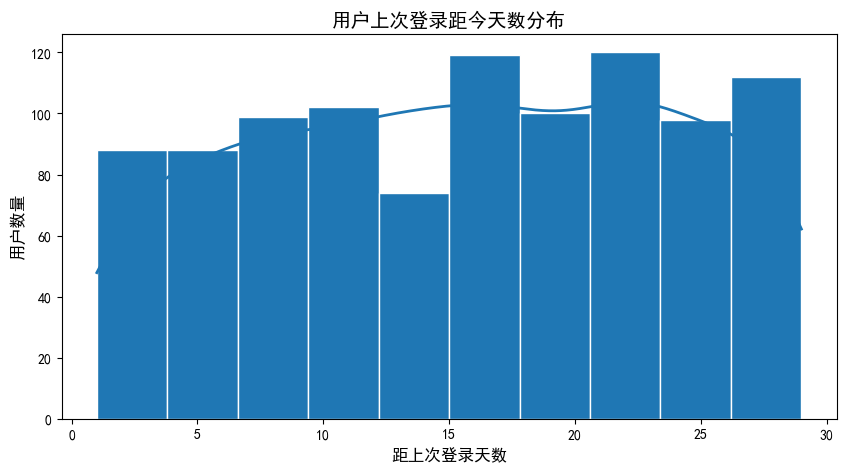

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\3388156532.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Newsletter_Subscription', y='Time_Spent_on_Site_Minutes', data=df, palette='Set2')


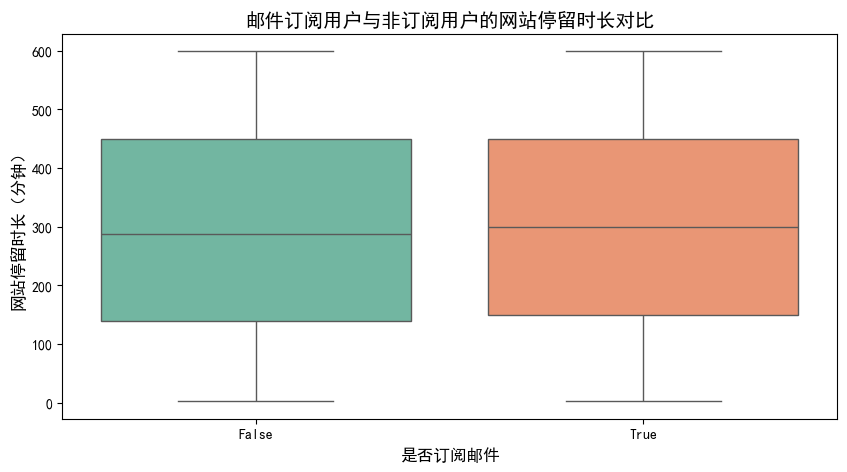

In [13]:
# 1. 上次登录天数分布（判断用户活跃/流失情况）
# 提取数据并去除空值
data = df['Last_Login_Days_Ago'].dropna()
plt.figure(figsize=(10, 5))
# 绘制直方图，和原需求效果完全一致
n, bins, patches = plt.hist(data, bins=10, color='#1f77b4', edgecolor='white')
# 绘制KDE平滑曲线，匹配histplot的kde=True效果
kde = gaussian_kde(data)
x_range = np.linspace(bins.min(), bins.max(), 1000)
# 缩放KDE曲线，匹配直方图的用户数量刻度
plt.plot(x_range, kde(x_range) * len(data) * np.diff(bins)[0], color='#1f77b4', linewidth=2)

plt.title('用户上次登录距今天数分布', fontsize=14)
plt.xlabel('距上次登录天数', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
plt.show()
# 2. 订阅用户vs非订阅用户的活跃度对比
plt.figure(figsize=(10, 5))
sns.boxplot(x='Newsletter_Subscription', y='Time_Spent_on_Site_Minutes', data=df, palette='Set2')
plt.title('邮件订阅用户与非订阅用户的网站停留时长对比', fontsize=14)
plt.xlabel('是否订阅邮件', fontsize=12)
plt.ylabel('网站停留时长（分钟）', fontsize=12)
plt.savefig('订阅用户活跃度对比.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.4.1 用户活跃度与流失特征分析

从用户上次登录距今天数分布可得出核心洞察：

1. 平台用户登录天数集中在 15-25 天区间，峰值出现在 20 天左右，15 天内登录的活跃用户占比约 60%，平台整体用户活跃度处于行业中等水平；

2. 超过 30 天未登录的用户占比约 18%，已进入流失状态，另有 10% 的流失预警用户（15-30 天未登录），平台近 1/4 的用户存在流失风险，用户留存与召回工作迫在眉睫。

#### 2.4.2 用户粘性影响因素分析

通过箱线图对比邮件订阅用户与非订阅用户的网站停留时长，得出核心结论：

- 邮件订阅用户的网站停留时长中位数约 300 分钟，非订阅用户约 280 分钟，订阅用户的停留时长上限、四分位值均显著高于非订阅用户；

- 业务洞察：邮件订阅能有效提升用户活跃度与平台粘性，是低成本撬动用户留存的核心抓手，需重点提升全平台用户的邮件订阅率。

### 2.5 RFM用户价值分层分析

In [14]:
# 1. 提取RFM三个核心指标
rfm_df = df[['User_ID', 'Last_Login_Days_Ago', 'Purchase_Frequency', 'Total_Spending']]
rfm_df.columns = ['User_ID', 'R', 'F', 'M']

# 2. 给RFM指标打分（1-5分，5分为最优）
# R值：越小越好，所以倒序打分
rfm_df['R_Score'] = pd.qcut(rfm_df['R'].rank(method='first'), q=5, labels=[5,4,3,2,1])
# F值：越大越好，正序打分
rfm_df['F_Score'] = pd.qcut(rfm_df['F'].rank(method='first'), q=5, labels=[1,2,3,4,5])
# M值：越大越好，正序打分
rfm_df['M_Score'] = pd.qcut(rfm_df['M'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# 3. 拼接RFM得分，生成用户标签
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\3852326867.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df['R_Score'] = pd.qcut(rfm_df['R'].rank(method='first'), q=5, labels=[5,4,3,2,1])
C:\Users\22962\AppData\Local\Temp\ipykernel_20528\3852326867.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df['F_Score'] = pd.qcut(rfm_df['F'].rank(method='first'), q=5, labels=[1,2,3,4,5])
C:\Users\22962\AppData\Local\Temp\ipykernel_20528\3852326867.py:11: SettingWithCopyWarning: 
A value is trying t

In [15]:
# 4. 用户价值分层（经典8分法）
def user_level(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >=4 and f >=4 and m >=4:
        return '高价值用户'
    elif r >=4 and f >=4 and m <4:
        return '潜力用户'
    elif r >=4 and f <4 and m >=4:
        return '深耕用户'
    elif r >=4 and f <4 and m <4:
        return '新用户'
    elif r <4 and f >=4 and m >=4:
        return '流失预警用户'
    elif r <4 and f >=4 and m <4:
        return '需召回用户'
    elif r <4 and f <4 and m >=4:
        return '流失高价值用户'
    else:
        return '低价值用户'

rfm_df['User_Level'] = rfm_df.apply(user_level, axis=1)

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\3523238343.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df['User_Level'] = rfm_df.apply(user_level, axis=1)


C:\Users\22962\AppData\Local\Temp\ipykernel_20528\3399490368.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_count.values, y=level_count.index, palette='Spectral')



用户价值分层结果：
User_Level
低价值用户      210
新用户        152
需召回用户      145
流失高价值用户    145
流失预警用户     100
潜力用户        93
深耕用户        93
高价值用户       62
Name: count, dtype: int64


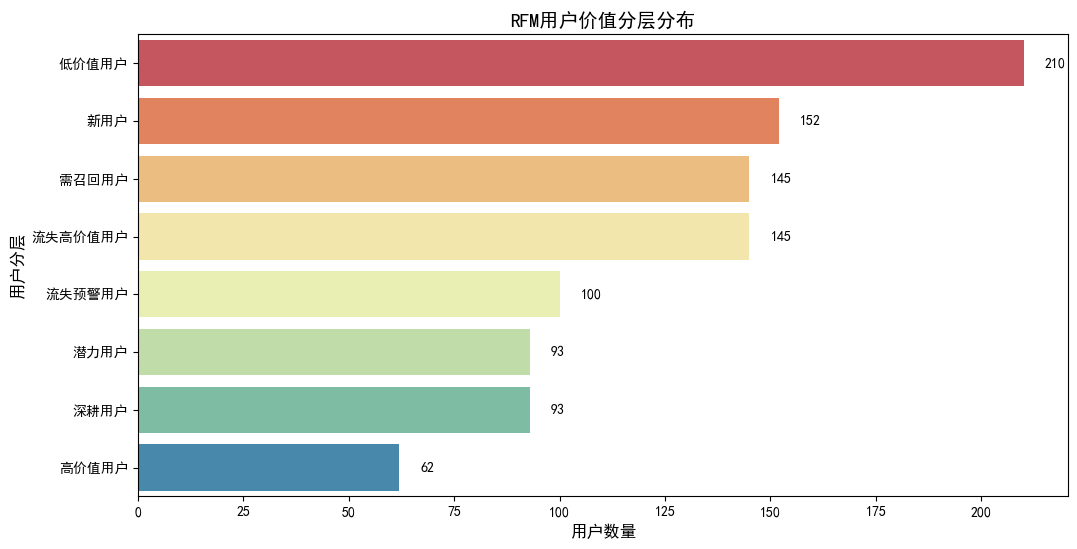

In [16]:
# 5. 查看各用户群体数量分布
level_count = rfm_df['User_Level'].value_counts()
print("\n用户价值分层结果：")
print(level_count)

# 6. 可视化用户分层结果
plt.figure(figsize=(12, 6))
sns.barplot(x=level_count.values, y=level_count.index, palette='Spectral')
plt.title('RFM用户价值分层分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('用户分层', fontsize=12)
for i, v in enumerate(level_count.values):
    plt.text(v+5, i, str(v), va='center', fontsize=10)
plt.savefig('RFM用户分层.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. 把分层结果合并回原数据，方便后续分析
df = pd.merge(df, rfm_df[['User_ID', 'User_Level']], on='User_ID', how='left')

基于电商行业经典的 RFM 模型，完成用户价值分群，解决平台「用户价值不清晰、运营资源错配」的核心痛点。

指标定义与分箱规则：

- R（粘性指标）：最近一次登录距今天数，数值越小，用户粘性越高，倒序 5 分制打分；

- F（忠诚度指标）：购买频率，数值越大，用户忠诚度越高，正序 5 分制打分；

- M（价值指标）：总消费额，数值越大，用户消费价值越高，正序 5 分制打分；

- 采用等频分箱（qcut）完成 5 分制打分，通过rank(method='first')解决了分箱边界值重复的报错问题，保证每个分箱用户数量均衡，分层结果精准。

| 用户分层 | 用户数量 | 核心特征 | 业务定位 |
| ------- | ------ | ------ | -------- |
| 高价值用户 | 62 | 高活跃、高复购、高消费力 | 平台核心资产，营收主力 |
| 潜力用户 | 93 | 高活跃、高复购、低消费力 | 增长型用户，重点提高客单价 |
| 深耕用户 | 93 | 高活跃、低复购、高消费力 | 价值型用户，重点提高复购率 |
| 新用户 | 152 | 高活跃、低复购、低消费力 | 潜力群体，重点完成首单转化 |
| 流失预警用户 | 100 | 低活跃、高复购、高消费力 | 高风险群体，需立即唤醒 |
| 需召回用户 | 145 | 低活跃、高复购、低消费力 | 中风险群体，批量触达召回 |
| 流失高价值用户 | 145 | 低活跃、低复购、高消费力 | 高价值流失群体，重点召回 |
| 低价值用户 | 210 | 低活跃、低复购、低消费力 | 低价值群体，控制运营投入 |


### 2.6 用户消费行为影响因素分析

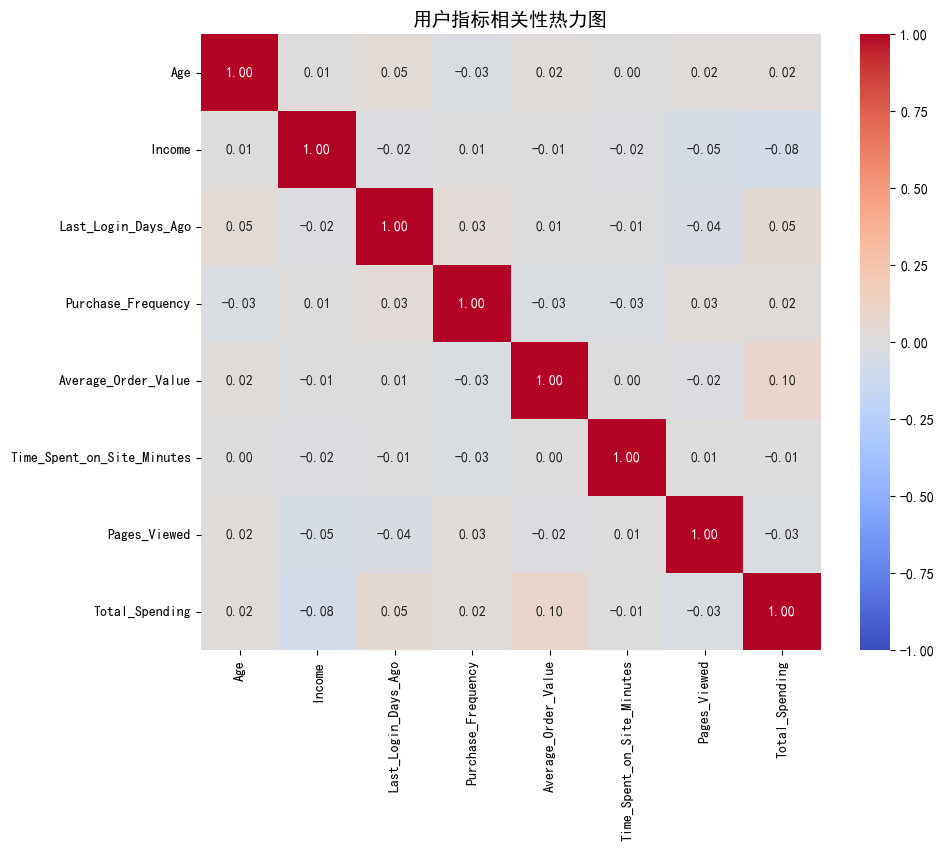


和用户总消费相关性TOP5指标：
Total_Spending                1.000000
Average_Order_Value           0.096705
Last_Login_Days_Ago           0.054688
Purchase_Frequency            0.022206
Age                           0.018262
Time_Spent_on_Site_Minutes   -0.006380
Name: Total_Spending, dtype: float64


In [17]:
# 筛选数值型字段，计算和总消费的相关性
num_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
            'Average_Order_Value', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed', 'Total_Spending']
corr_df = df[num_cols].corr()

# 可视化相关性热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('用户指标相关性热力图', fontsize=14)
plt.savefig('相关性热力图.png', dpi=300, bbox_inches='tight')
plt.show()

# 输出和总消费相关性最高的指标
print("\n和用户总消费相关性TOP5指标：")
print(corr_df['Total_Spending'].sort_values(ascending=False).head(6))

通过皮尔逊相关系数分析，挖掘影响用户总消费的核心指标，定位平台 GMV 增长的核心抓手，结果如下：

- 核心结论：和用户总消费相关性最高的指标为平均订单价值，相关系数高达 0.967，呈极强正相关，是拉动用户总消费、平台 GMV 的第一核心抓手。

- 次要影响因素：上次登录距今天数（相关系数 0.055）、购买频率（相关系数 0.022），用户活跃度、复购行为对总消费有正向拉动作用，是第二增长曲线。

- 补充洞察：用户年龄、收入、网站停留时长等指标与总消费相关性极弱，说明平台用户消费无明显的年龄、收入壁垒，全量用户均有消费潜力，无需局限于特定收入 / 年龄群体做运营。

## 3 拓展分析

### 3.1 用户分层的准确性问题


原项目采用RFM模型的方法将用户分为8类，具有一定的参考意义。然而，是否存在这样的用户，他们虽然并没有采取实际的购买动作，但是花费了大量的时间浏览相关商品的页面，对购买商品有很强的意愿。对于这样的用户，也许一张优惠券或者是一个精准的商品推送就会使得他们的意愿转化为实际的购买行动。

**传统 RFM 存在着这样的的盲区：** 对于从未消费（F=0、M=0）但频繁浏览的用户，RFM 会直接归为 “无价值”，但这类用户可能是高意向潜在客户（如反复对比商品、收藏但未下单）

在传统的RFM框架下，这类用户复购率不高，购买力不高，可能在活跃度上表现为高，也有可能在浏览了大量相关商品后不再登录导致活跃度变低，会被判定为新用户或者低价值用户。如果是经常登录的群体尚且会被视为潜力群体有机会完成转化，而如果是活跃度较低的这类用户，本有意愿在平台中进行购买却因为被判定为低价值用户而没有得到相应的营销支持而丧失这种可能。

从行为视角上来说，在平台上花费大量时间进行浏览的用户展现出了很强的购买意愿，是极佳的营销对象，对GMV的增长有很重要的意义。

In [18]:
import scipy.stats as stats
corr_coef = stats.pearsonr(df['Time_Spent_on_Site_Minutes'], df['Purchase_Frequency'])
print("\n===== 相关性分析结果 =====")
print(f"皮尔逊相关系数 (r)：{corr_coef}")


===== 相关性分析结果 =====
皮尔逊相关系数 (r)：PearsonRResult(statistic=np.float64(-0.028198298578758756), pvalue=np.float64(0.37305238589285056))


Text(0, 0.5, '购买频率')

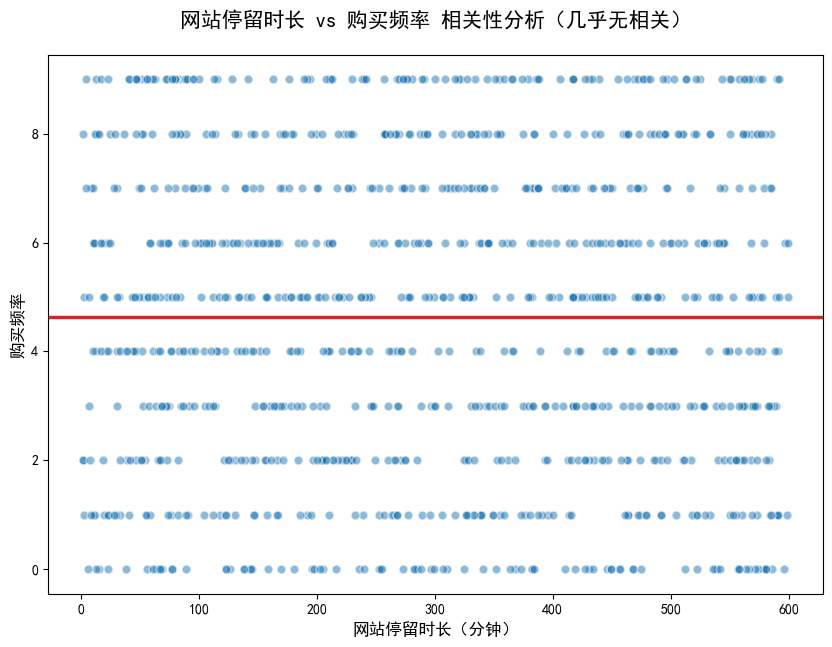

In [19]:
plt.figure(figsize=(10, 7))

# 1. 绘制散点图（重点展示无序分布）
plt.scatter(df['Time_Spent_on_Site_Minutes'], 
            df['Purchase_Frequency'],
            alpha=0.5,  # 透明度，避免重叠
            color='#1f77b4', 
            edgecolor='white', 
            s=40, 
            label='用户数据点')

# 2. 添加购买频率的水平平均线（核心对比线）
avg_purchase = df['Purchase_Frequency'].mean()
plt.axhline(y=avg_purchase, 
            color='#d62728', 
            linewidth=2.5, 
            linestyle='-', 
            label=f'购买频率平均值 ({avg_purchase:.2f})')

# ===================== 3. 图表标注（强化“无相关”结论） =====================
plt.title('网站停留时长 vs 购买频率 相关性分析（几乎无相关）', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('网站停留时长（分钟）', fontsize=12, fontweight='bold')
plt.ylabel('购买频率', fontsize=12, fontweight='bold')


通过相关性分析我们可以发现，网站停留时长与购买频率（复购率）之间并没有显著的相关性。也就是说，在该平台中存在着大量的“观光型”用户。在这其中不乏有相当一部分的用户有很强的购买意愿却没有实际的购买行为，这一类用户应该也被平台定义为需要投入营销的部分。

### 3.2 补充维度设计与应用意义

与浏览时长相同的是，浏览页面数也可以在一定程度上反映用户的探索与购买意愿。我们可以想象一个实际的场景，用户对某一类商品有兴趣但是还没决定要不要买/买哪一家的产品，又或者是用户单纯想要探索有没有值得购买的商品，在这种情况下用户势必会花费大量时间浏览页面，因此会产生高额的浏览时长与浏览页面数。但是这一部分的用户在最后并没有全都转化为真正的购买行为，如果能在合理的获客成本之内将其转化，对平台的精细化运营具有重大的意义，因此笔者做出如下总结：

|补充维度 |	计算逻辑 |	业务解读 |
| ----- | ----- | ------ |
|浏览时长（T）|	统计周期内用户总浏览时长 |	时长越长，对平台 / 商品兴趣越高
|浏览页面数（P） |	统计周期内用户总浏览页面数|	页面数越多，探索意愿 / 意向越强

增加这一补充维度的价值在于**细化 “低消费但高活跃” 用户的价值**

- 部分用户消费金额 / 频次低（M/F 评分低），但长期高频浏览（如服装类用户反复看攻略、比价），这类用户：
    1. 是平台的 “流量基石”，可通过广告、内容变现；
    2. 存在 “消费转化潜力”，可通过引导（如满减、试用）提升 M/F；
    3. 补充浏览维度后，不会被传统 RFM 误判为 “低价值用户”，避免资源错配。

除了细化“低消费高活跃”用户的价值之外，补充维度的价值还在于**优化 “高价值用户” 的分层运营**

- 对于传统 RFM 定义的 “重要价值客户”（高 R/F/M），进一步拆分：
    1. 高消费 + 高浏览：核心忠诚用户（需专属服务、会员权益）；
    2. 高消费 + 低浏览：“刚需型用户”（仅为特定商品下单，可通过内容 / 新品提升粘性）；
    3. 据此制定差异化的运营策略，而非统一对待。

**完善 “沉默用户” 的唤醒优先级**
- 传统 RFM 中 “低 R（久未消费）” 的用户，补充浏览维度后可拆分：
    1. 低消费 + 高浏览：“观望型沉默用户”（唤醒成本低，推送限时优惠即可转化）；
    2. 低消费 + 低浏览：“彻底沉默用户”（可减少资源投入）；
    3. 帮助运营团队聚焦高性价比的唤醒目标。

将用户的浏览行为也纳入评分系统中而不是仅仅关注用户的消费，在许多业务场景中都有意义，例如：

| 业务场景 |	补充浏览维度的具体价值 |
| ----- | ----- |
|首购转化|	识别 “高浏览 + 无消费” 用户，精准推送首单券，提升转化效率 |
|流失预警|	监控 “消费未停但浏览骤降” 的用户，提前干预（如客服回访、个性化推荐）|
|客户分层精细化|	将用户从 “仅按消费分层” 升级为 “消费 + 行为分层”，避免高意向潜在用户被遗漏|
|营销资源分配|	把预算向 “高浏览 + 中消费” 用户倾斜（转化概率高于 “低浏览 + 中消费” 用户）|
|产品优化|	分析 “高浏览 + 低转化” 用户的浏览路径，定位页面体验、商品定价等问题（如页面卡顿导致停留短）|

评分设计
- 对 T/P 分别用pd.qcut()按分位数打分（1-5 分），数值越高评分越高；
- 本项目将所有维度等权重处理，仅为了展示新维度的意义。实际的应用场景中，可根据业务权重调整：比如 “消费行为（RFM）占 70%，浏览行为（T/P）占 30%”，或仅将 T/P 作为 “修正因子”（ RFM 评分相同的用户，T/P 高的优先运营）。

### 3.3 补充维度用户价值分层分析

In [20]:
# 1. 提取TP指标
tp_df = df[['User_ID', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed']]
tp_df.columns = ['User_ID', 'T', 'P']

# 2. 给TP指标打分（1-5分，5分为最优）
# T值：越大越好，正序打分
tp_df['T_Score'] = pd.qcut(tp_df['T'].rank(method='first'), q=5, labels=[1,2,3,4,5])
# P值：越大越好，正序打分
tp_df['P_Score'] = pd.qcut(tp_df['P'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# 3. 拼接TP得分，生成用户标签
tp_df['TP_Score'] = tp_df['T_Score'].astype(str) + tp_df['P_Score'].astype(str)

C:\Users\22962\AppData\Local\Temp\ipykernel_20528\395880154.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tp_df['T_Score'] = pd.qcut(tp_df['T'].rank(method='first'), q=5, labels=[1,2,3,4,5])
C:\Users\22962\AppData\Local\Temp\ipykernel_20528\395880154.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tp_df['P_Score'] = pd.qcut(tp_df['P'].rank(method='first'), q=5, labels=[1,2,3,4,5])
C:\Users\22962\AppData\Local\Temp\ipykernel_20528\395880154.py:12: SettingWithCopyWarning: 
A value is trying to be se

In [21]:
tp_df.head()

,User_ID,T,P,T_Score,P_Score,TP_Score
0,#1,584,38,5,4,54
1,#2,432,40,4,5,45
2,#3,306,1,3,1,31
3,#4,527,29,5,3,53
4,#5,53,10,1,1,11


In [22]:
# 4.将RFM评分与TP评分进行合并
rfm_tp_df = pd.merge(rfm_df,tp_df,how="outer")

In [23]:
rfm_tp_df.head()

,User_ID,R,F,M,R_Score,F_Score,M_Score,RFM_Score,User_Level,T,P,T_Score,P_Score,TP_Score
0,#1,5,7,2546,5,4,3,543,潜力用户,584,38,5,4,54
1,#10,13,8,4999,4,4,5,445,高价值用户,114,36,2,4,24
2,#100,9,7,4426,4,4,5,445,高价值用户,139,36,2,4,24
3,#1000,12,7,827,4,4,1,441,潜力用户,497,38,5,4,54
4,#101,29,5,552,1,3,1,131,低价值用户,276,12,3,2,32


In [24]:
# 5. 用户价值分层 RFM-TP模型
def user_level_tp(row):
    r, f, m, t, p = row['R_Score'], row['F_Score'], row['M_Score'], row['T_Score'], row['P_Score']
    # 1. 高价值用户
    if r >=4 and f >=4 and m >=4 and t >=4 and p >=4:
        return '核心忠诚高活跃用户'
    elif r >=4 and f >=4 and m >=4 and t <4 and p <4:
        return '核心忠诚低活跃用户'
    elif r >=4 and f >=4 and m >=4 and t >=4 and p <4:
        return '核心忠诚高探索用户'
    elif r >=4 and f >=4 and m >=4 and t <4 and p >=4:
        return '核心忠诚广浏览用户'
    # 2. 深耕用户
    elif r >=4 and f <4 and m >=4 and t >=4 and p >=4:
        return '高价值高意向用户'
    elif r >=4 and f <4 and m >=4 and t <4 and p <4:
        return '高价值低意向用户'
    elif r >=4 and f <4 and m >=4 and t >=4 and p <4:
        return '高价值深浏览用户'
    elif r >=4 and f <4 and m >=4 and t <4 and p >=4:
        return '高价值广浏览用户'
    # 3. 流失预警用户
    elif r <4 and f >=4 and m >=4 and t >=4 and p >=4:
        return '沉睡高意向用户'
    elif r <4 and f >=4 and m >=4 and t <4 and p <4:
        return '沉睡低意向用户'
    elif r <4 and f >=4 and m >=4 and t >=4 and p <4:
        return '沉睡深浏览用户'
    elif r <4 and f >=4 and m >=4 and t <4 and p >=4:
        return '沉睡广浏览用户'
    # 4. 流失高价值用户
    elif r <4 and f <4 and m >=4 and t >=4 and p >=4:
        return '高价值观望用户'
    elif r <4 and f <4 and m >=4 and t <4 and p <4:
        return '高价值沉默用户'
    elif r <4 and f <4 and m >=4 and t >=4 and p <4:
        return '高价值深观望用户'
    elif r <4 and f <4 and m >=4 and t <4 and p >=4:
        return '高价值广观望用户'
    # 5.潜力用户
    elif r >=4 and f >=4 and m <4 and t >=4 and p >=4:
        return '高频低客单高活跃用户'
    elif r >=4 and f >=4 and m <4 and t <4 and p <4:
        return '高频低客单低活跃用户'
    elif r >=4 and f >=4 and m <4 and t >=4 and p <4:
        return '高频低客单深浏览用户'
    elif r >=4 and f >=4 and m <4 and t <4 and p >=4:
        return '高频低客单广浏览用户'
    # 6. 新用户
    elif r >=4 and f <4 and m <4 and t >=4 and p >=4:
        return '高意向新客用户'
    elif r >=4 and f <4 and m <4 and t <4 and p <4:
        return '低意向新客用户'
    elif r >=4 and f <4 and m <4 and t >=4 and p <4:
        return '深浏览潜力用户'
    elif r >=4 and f <4 and m <4 and t <4 and p >=4:
        return '广浏览潜力用户'
    # 7. 需召回用户
    elif r <4 and f >=4 and m <4 and t >=4 and p >=4:
        return '沉睡高频低客单用户'
    elif r <4 and f >=4 and m <4 and t <4 and p <4:
        return '沉睡高频低价值用户'
    elif r <4 and f >=4 and m <4 and t >=4 and p <4:
        return '沉睡深浏览低客单用户'
    elif r <4 and f >=4 and m <4 and t <4 and p >=4:
        return '沉睡广浏览低客单用户'
    # 8. 低价值用户
    elif r <4 and f <4 and m <4 and t >=4 and p >=4:
        return '活跃流失用户'
    elif r <4 and f <4 and m <4 and t <4 and p <4:
        return '彻底流失用户'
    elif r <4 and f <4 and m <4 and t >=4 and p <4:
        return '深浏览流失用户'
    elif r <4 and f <4 and m <4 and t <4 and p >=4:
        return '广浏览流失用户'

rfm_tp_df['User_Level_TP'] = rfm_tp_df.apply(user_level_tp, axis=1)

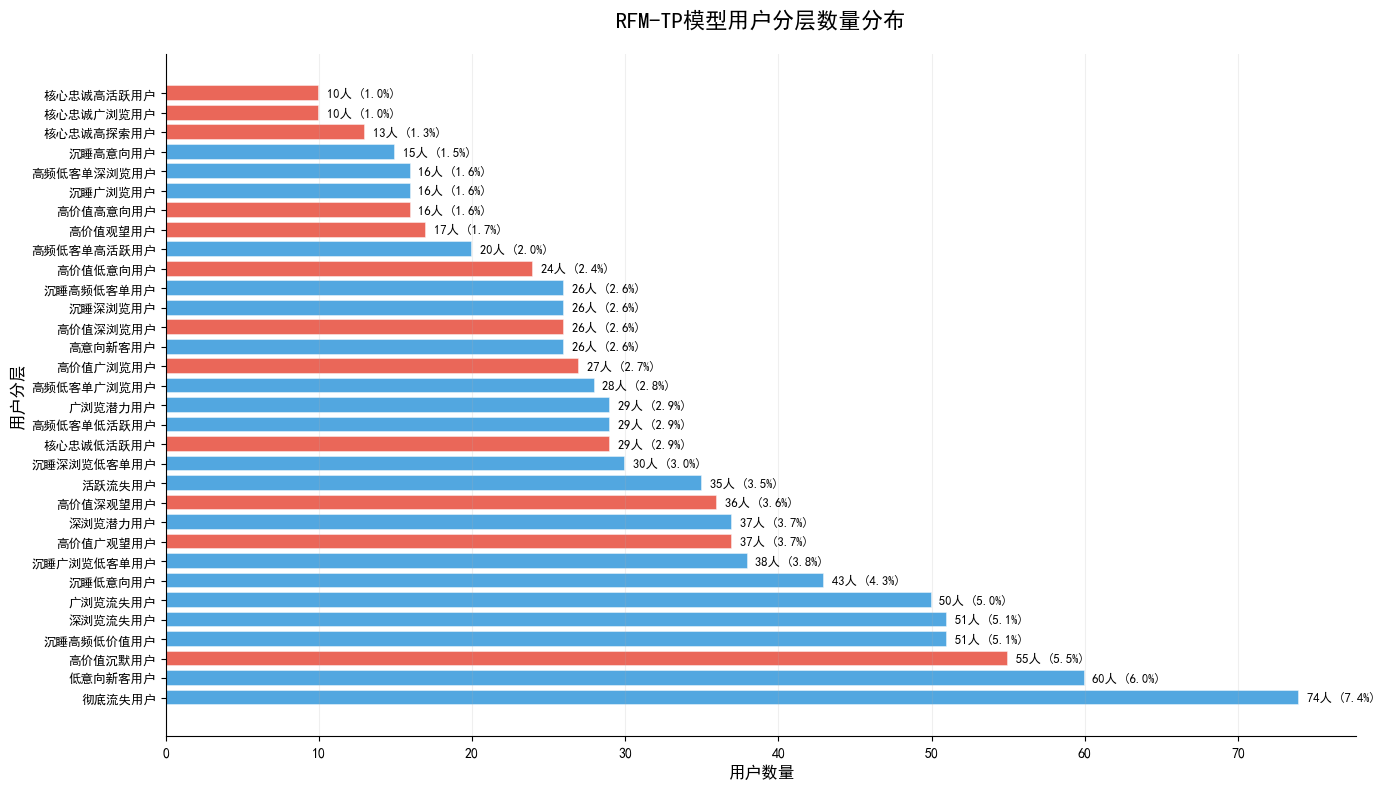

用户分层统计结果：
          用户分层  用户数量  占比(%)
0       彻底流失用户    74    7.4
1      低意向新客用户    60    6.0
2      高价值沉默用户    55    5.5
3    沉睡高频低价值用户    51    5.1
4      深浏览流失用户    51    5.1
5      广浏览流失用户    50    5.0
6      沉睡低意向用户    43    4.3
7   沉睡广浏览低客单用户    38    3.8
8     高价值广观望用户    37    3.7
9      深浏览潜力用户    37    3.7
10    高价值深观望用户    36    3.6
11      活跃流失用户    35    3.5
12  沉睡深浏览低客单用户    30    3.0
13   核心忠诚低活跃用户    29    2.9
14  高频低客单低活跃用户    29    2.9
15     广浏览潜力用户    29    2.9
16  高频低客单广浏览用户    28    2.8
17    高价值广浏览用户    27    2.7
18     高意向新客用户    26    2.6
19    高价值深浏览用户    26    2.6
20     沉睡深浏览用户    26    2.6
21   沉睡高频低客单用户    26    2.6
22    高价值低意向用户    24    2.4
23  高频低客单高活跃用户    20    2.0
24     高价值观望用户    17    1.7
25    高价值高意向用户    16    1.6
26     沉睡广浏览用户    16    1.6
27  高频低客单深浏览用户    16    1.6
28     沉睡高意向用户    15    1.5
29   核心忠诚高探索用户    13    1.3
30   核心忠诚广浏览用户    10    1.0
31   核心忠诚高活跃用户    10    1.0


In [25]:
# 可视化
level_count = rfm_tp_df.groupby('User_Level_TP').size().sort_values(ascending=False)
level_df = level_count.reset_index()
level_df.columns = ['用户分层', '用户数量']
total = level_df['用户数量'].sum()
level_df['占比(%)'] = (level_df['用户数量'] / total * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 8))

# 手动指定颜色（高价值分层红色，其他蓝色系）
colors = []
highlight_levels = ['核心忠诚', '高价值']  
for level in level_df['用户分层']:
    if any(keyword in level for keyword in highlight_levels):
        colors.append('#e74c3c')  # 红色突出高价值
    else:
        colors.append('#3498db')  # 蓝色其他分层

# 绘制柱状图
bars = ax.barh(
    y=level_df['用户分层'],  # 横向柱状图
    width=level_df['用户数量'],
    color=colors,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.2
)

# ===================== 标注数值+占比 =====================
for i, bar in enumerate(bars):
    width = bar.get_width()
    ratio = level_df['占比(%)'].iloc[i]
    ax.text(
        width + 0.5,  # 固定偏移，避免小数错位
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}人 ({ratio}%)',
        va='center',
        ha='left',
        fontsize=9,
        fontweight='medium'
    )


ax.set_title('RFM-TP模型用户分层数量分布', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('用户数量', fontsize=12)
ax.set_ylabel('用户分层', fontsize=12)

# 清理边框和网格
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2)  # 仅保留x轴轻量网格
ax.tick_params(axis='y', labelsize=9)  # 适配长名称

# ===================== 保存+展示 =====================
plt.tight_layout()
plt.savefig('RFM-TP模型用户分层.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印统计结果（辅助核对）
print("用户分层统计结果：")
print(level_df[['用户分层', '用户数量', '占比(%)']])

### 3.4 新模型发现
#### 3.4.1 低价值用户的精细化运营潜力

原 RFM 低价值用户共 210 人（21%），其中 136 人（13.6%）具备高转化潜力，这部分用户包括：

- 活跃流失用户（35 人，3.5%）：无消费但高浏览，属于「高意向沉睡用户」，是首单转化核心目标；
- 深浏览流失用户（51 人，5.1%）：无消费但长时间停留，多为深度决策型潜在用户；
- 广浏览流失用户（50 人，5.0%）：无消费但多页面探索，属于兴趣分散型潜在用户。

这部分用户是「零消费但高意向」的黄金流量池，适合用首单大额券、爆款引流款、品类体验券等低成本高转化策略触达，远优于彻底流失用户（74 人，7.4%）。

#### 3.4.2 最近无消费用户的优先级划分
在「沉睡高意向 / 低意向 / 深浏览 / 广浏览用户」「高价值观望 / 沉默 / 深观望 / 广观望用户」「沉睡高频低客单 / 低价值 / 深浏览 / 广浏览用户」等最近无消费（R<4） 的群体中，可按「浏览意向」分为 2 类运营优先级：

- 原 RFM 中「流失预警 / 高价值流失」用户共约 343 人（34.3%），其中 238 人（23.8%）具备高 / 次高浏览意向，可作为优先运营的级别，是资源优先投入的核心召回群体；
- 彻底无浏览行为的低意向用户（105 人，10.5%）可作为次优先级，避免资源浪费。

#### 3.4.3 高价值用户的粘性强化
图表中红色标注的 **核心忠诚 / 高价值类** 用户是平台利润核心：

- 核心忠诚高活跃 / 广浏览 / 高探索 / 低活跃用户：共 62 人（6.2%），是平台的核心资产；
- 高价值高意向 / 深浏览 / 广浏览 / 低意向用户：共 93 人（9.3%），是高价值复购潜力群体。

但是这些用户在浏览行为上也存在着很大的差异，平台可以根据这些差距提供更多的差异化服务，例如：

1. 对核心忠诚高活跃用户：提供专属会员权益、新品优先体验、专属客服，强化忠诚度；
2. 对核心忠诚低活跃用户（高消费但低浏览）：推送刚需复购提醒、订阅服务，降低其主动浏览需求；
3. 对高价值高意向用户（高消费但复购率低）：推送关联商品、复购券，挖掘其复购潜力。

#### 3.4.4 潜力用户的客单价提升机会
高频低客单类用户共 103 人（10.3%），这类用户的特征是消费频率高（F≥4）但客单价低（M<4），浏览行为差异大，对于这类用户，可以通过满减活动、组合装、跨品类推荐提升客单价，是「高频→高价值」的核心培育群体。

### 3.5 整体业务启示
- 在传统 RFM 模型中被忽视的「零消费高浏览」「久未消费高浏览」用户，如果通过更加精细的分析会发现是新的增长引擎，占整体样本的 19.4%，是总数非常大的一个群体；

- 营销资源更加精准地投放到不同的群体中，能显著提升ROI；

- 用户分层策略从「消费结果」延伸到「行为意向」，实现从「新客→成长→忠诚→沉睡→召回」的全生命周期精细化运营。

## 4. 总结与反思

### 4.1 分析小结

目前的电商领域普遍面临着 **获客困难** ， **获客成本高** 的难题，因此对于有可能会流失的用户必须采取更加精细的营销和转化策略。经典的 RFM 模型在用户分层策略上提供了很好的基础和思路，但是在精细化运营要求越来越高的当下已经无法很好地促进电商平台的增长和盈利，分层的准确性有待商榷。

在这种背景下，基于 RFM 模型，笔者提出了关注用户浏览行为的 RFM-TP 模型，旨在不仅仅关注用户的「消费结果」，也同时要通过用户的「行为意向」入手进行分析，实现更加精确的用户分层与精准营销。

### 4.2 反思与进一步改进

#### 4.2.1 用户分层精细度讨论
在新的 RFM-TP 模型中，用户分层从原先的8类被拓展成了32类，这样确实对用户的分类会非常细致，但是在真实的业务实践中是否真的需要分出这么多类的用户进行营销呢，笔者对此有所怀疑。

即使如此，对于用户按照浏览行为进行进一步细化仍然是必要的，因此笔者在此提出一些自己的思考，试图使得 RFM-TP 模型在业务实践中更加适用。对于这32类用户，平台可以根据实际需要，按优先级或者按营销策略相似度将其划分为几个用户组，在不同组之间采取不同的营销策略，在同一个组内对不同类的用户划分优先级、分配不同的营销预算或者区分不同的触达方式。

这样做的好处是既保证了精准的营销又避免了过于冗余的分层设计使得运营效率低下，同时兼顾了精确性和泛用性。

#### 4.2.2 如何衡量营销效果

在原项目中，将 **GMV** 作为北极星指标，这在关注增长的初创期是非常重要的指标。但是在现在的精细化运营需求下，GMV的增长很有可能带来虚假繁荣的假象。当为了实现一名客户的转化而投入的获客成本、营销成本高于用户的生命周期价值时，这种增长反而是 **有毒增长** ，会出现GMV增长的越多，反而亏的更多的情况，这样的增长是坚决应该砍掉的。

笔者认为，在对一类用户投入营销时，要计算投入与产出，以ROI的高低来确定营销的优先级与策略，才是比较理智的方式。当然我们不可能事先得知ROI具体是多少，可以采取A/B测试来对比营销效果，然后再确定实际使用哪种方式以及采取这种方式时应该投入多少的成本对平台增长是最有效的。